# Viewing the AXI-Streaming Timing

In this notebook, we show how to parse and view timing on AXI-Streaming data from a VCD file.

## Reading the VCD file

Select the demo you wish to see the timing diagram for:

- `demo = 'avgfilt'`:  This is for the pure AXI streaming squared average in `avgfilt.cpp`
- `demo = 'poly_block'`:  This is for block-based AXI streaming in  `poly_block.cpp`

In [102]:
# Set the demo ('poly_block' or 'avgfilt')
demo = 'poly_block' 

Next, we read the VCD file.  Both demos overwrite the VCD file.  So you have to re-run the demo before running this notebook.

In [103]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

In [104]:
# Check if VCD file exists
if demo == 'avgfilt':
    vcd_file = 'dump_avg.vcd'
else:
    vcd_file = 'dump_poly.vcd'
import os
fn = os.path.join(os.getcwd(), '..', 'stream_vitis', 'vcd', vcd_file)
if not os.path.exists(fn):
    raise FileNotFoundError(f"VCD file not found: {fn}")

# Parse the VCD file
vcd = VCDVCD(fn, signals=None, store_tvs=True)

In [105]:
nsig = len(vcd.signals)
print(f"Number of signals in VCD: {nsig}")

# Find the signals with TDATA and TREADY in their names
tdatas = [s for s in vcd.signals if 'TDATA' in s]
print(tdatas)




Number of signals in VCD: 839
['apatb_poly_block_top.cmd_stream_TDATA[31:0]', 'apatb_poly_block_top.resp_stream_TDATA[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TDATA[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TDATA[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TDATA_blk_n', 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TDATA_blk_n', 'apatb_poly_block_top.AESL_inst_poly_block.grp_poly_block_Pipeline_proc_loop_fu_101_resp_stream_TDATA[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.grp_stream_write_axis_ap_int_32_0ul_0ul_0ul_unsigned_char_56_false_s_fu_125_resp_stream_TDATA[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TDATA_reg[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TDATA_int_regslice[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TDATA_int_regslice[31:0]', 'apatb_poly_block_top.AESL_inst_poly_block.grp_poly_block_Pipeline_proc_loop_fu_101.cmd_stream_TDATA[31:0]', 

## Parsing and Viewing the VCD files

We now load utilities from the `xilinxutils` package to parse the VCD file and view the timing diagrams.

In [106]:
import importlib

import xilinxutils
import xilinxutils.vcd
importlib.reload(xilinxutils)
importlib.reload(xilinxutils.vcd)

from xilinxutils.vcd import VcdParser
from xilinxutils.timing import TimingDiagram


In [107]:
# Create a parsing class
vp = VcdParser(vcd)

# Get the clock signal name
clk_name = vp.add_clock_signal()

if demo == 'poly_block':
    top_name = 'AESL_inst_poly_block'
    in_stream_name = f"{top_name}.cmd_stream_"
    out_stream_name = f"{top_name}.resp_stream_"
elif demo == 'avgfilt':
    top_name = 'apatb_avgfilt_top'
    in_stream_name = f"{top_name}.in_stream_"
    out_stream_name = f"{top_name}.out_stream_"
    
# Get the  AXI-Stream command signals
in_str_sigs, in_bw = vp.add_axiss_signals(name=in_stream_name, short_name_prefix='in_stream',
                                           ignore_multiple=True)
print(in_str_sigs)

# Get the output AXI-Stream signals
out_str_sigs, out_bw = vp.add_axiss_signals(name=out_stream_name, short_name_prefix='out_stream',
                                            ignore_multiple=True)
print(out_str_sigs)




{'tdata': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TVALID', 'tready': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TREADY', 'tlast': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TLAST[0:0]'}
{'tdata': 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TVALID', 'tready': 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TREADY', 'tlast': 'apatb_poly_block_top.AESL_inst_poly_block.resp_stream_TLAST[0:0]'}


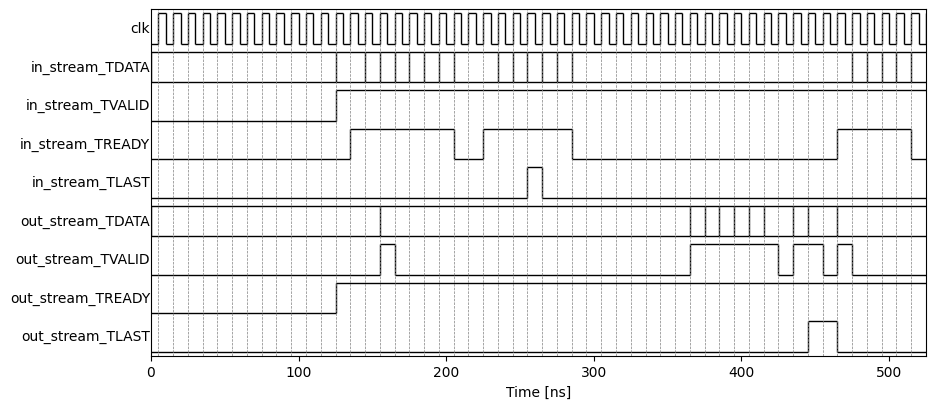

In [108]:
# Get the timing signals
sig_list = vp.get_td_signals()

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

In [109]:
sigs = list(in_str_sigs.keys())
in_str_sigs

{'tdata': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TDATA[31:0]',
 'tvalid': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TVALID',
 'tready': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TREADY',
 'tlast': 'apatb_poly_block_top.AESL_inst_poly_block.cmd_stream_TLAST[0:0]'}

In [110]:
import datastructs 
importlib.reload(xilinxutils.vitisstructs)
from xilinxutils.vitisstructs import VitisStruct, uint_to_float

importlib.reload(datastructs)

# Create data structure objects from the the
# field definitions in datastructs.py
cmd_hdr = VitisStruct('CmdHdr', datastructs.cmd_hdr_fields)
res_hdr = VitisStruct('RespHdr', datastructs.resp_hdr_fields)
res_foot = VitisStruct('RespFooter', datastructs.resp_footer_fields)

nwords_cmd_hdr = cmd_hdr.get_length()

print('Reading command stream from VCD bursts:')
bursts_in, clk_period= vp.extract_axis_bursts(clk_name, in_str_sigs)
burst_in = bursts_in[0]

print('Cmd header fields:')
data = burst_in['data']
cmd_hdr_data = data[:nwords_cmd_hdr].reshape((-1,1))
cmd_hdr.read_stream(cmd_hdr_data)
for k, v in cmd_hdr.data.items():
    print(f"   {k}: {v}")

print('\nInput data words:')
xdata_unit = data[nwords_cmd_hdr:]
xdata = uint_to_float(xdata_unit)
print(xdata)
n = len(xdata)

# Read the output stream bursts and 
# parse the response header, data, and footer

print('Reading command stream from VCD bursts:')
bursts_out, clk_period= vp.extract_axis_bursts(clk_name, out_str_sigs)
burst_out = bursts_out[0]
out_data = burst_out['data']

print('\nResponse header fields:')
resp_hdr_len = res_hdr.get_length()
resp_hdr_data = out_data[:resp_hdr_len].reshape((-1,1))
res_hdr.read_stream(resp_hdr_data)
for k, v in res_hdr.data.items():
    print(f"   {k}: {v}")

ydata_unit = out_data[resp_hdr_len:resp_hdr_len+n]
ydata = uint_to_float(ydata_unit)
print('\nOutput data words:')
print(ydata)

print('\nResponse footer fields:')
resp_foot_len = res_foot.get_length()
resp_foot_data = out_data[resp_hdr_len+n:resp_hdr_len+n+resp_foot_len].reshape((-1,1))
res_foot.read_stream(resp_foot_data)
for k, v in res_foot.data.items():
    print(f"   {k}: {v}")



Reading command stream from VCD bursts:
Cmd header fields:
   trans_id: 42
   a0: 1.0
   a1: 2.0
   a2: 0.5
   n: 6

Input data words:
[ 0.  1.  2. -1.  3.  4.]
Reading command stream from VCD bursts:

Response header fields:
   trans_id: 42

Output data words:
[ 1.   3.5  7.  -0.5 11.5 17. ]

Response footer fields:
   nread: 6
   err_code: ErrCodes.NO_ERR


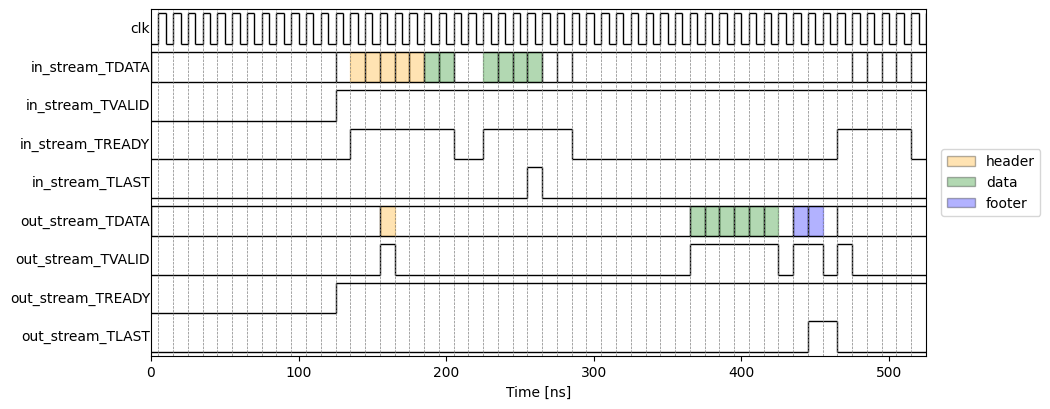

In [112]:
# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

from matplotlib.patches import Patch


def color_beats(burst, sig_name, clk_period, hdr_len, data_len):
    # Set colors for parts of field
    hdr_color = 'orange'
    data_color = 'green'
    footer_color = 'blue'
    t0 = burst['tstart']
    beat_type = burst['beat_type']
    types = []
    j = 0
    for i, bt in enumerate(beat_type):
    
        if bt != 0:
            continue
        if (j < hdr_len):
            color = hdr_color
        elif (j < hdr_len + data_len):
            color = data_color
        else:
            color = footer_color
        j += 1

        time = [t0+i*clk_period, t0+(i+1)*clk_period]
        td.add_patch(sig_name=sig_name, time=time,
            color=color, alpha=0.3)

# Add patches to indicate the components 
cmd_hdr_len = cmd_hdr.get_length()
data_len = len(xdata)
color_beats(burst_in, 
            sig_name='in_stream_TDATA', 
            clk_period=clk_period, 
            hdr_len=cmd_hdr_len, 
            data_len=data_len)

# Add paths for response header, data, and footer
res_hdr_len = res_hdr.get_length()
color_beats(burst_out, 
            sig_name='out_stream_TDATA', 
            clk_period=clk_period, 
            hdr_len=res_hdr_len, 
            data_len=data_len)

legend_elements = [
    Patch(facecolor='orange', edgecolor='black', alpha=0.3, label='header'),
    Patch(facecolor='green', edgecolor='black', alpha=0.3, label='data'),
    Patch(facecolor='blue', edgecolor='black', alpha=0.3, label='footer'),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)


In [41]:
burst_in

{'data': array([        42, 1065353216, 1073741824, 1056964608,          6,
                 0, 1065353216, 1073741824, 3212836864, 1077936128,
        1082130432], dtype=uint32),
 'start_idx': 13,
 'beat_type': [0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0],
 'tstart': np.float64(135.0)}